In [50]:
# necessary imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.inspection import DecisionBoundaryDisplay

# 1. Loading dataset

In [2]:
# loading a dataset from openml
from sklearn.datasets import fetch_openml
dataset = fetch_openml(data_id=43463)

In [3]:
df = dataset.frame
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Checking for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Checking for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of duplicate rows:
1


# 2. Dataset Splitting

In [36]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print("Training set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)
print("Test set shape:", test_df.shape)

Training set shape: (936, 7)
Validation set shape: (201, 7)
Test set shape: (201, 7)


# 3. Feature Preprocessing

In [37]:
categorical_cols = train_df.select_dtypes(include=['object']).columns

train_df_encoded = pd.get_dummies(train_df, columns=categorical_cols, dummy_na=False)
val_df_encoded = pd.get_dummies(val_df, columns=categorical_cols, dummy_na=False)
test_df_encoded = pd.get_dummies(test_df, columns=categorical_cols, dummy_na=False)

train_cols = train_df_encoded.columns
val_cols = val_df_encoded.columns
test_cols = test_df_encoded.columns

missing_in_val = set(train_cols) - set(val_cols)
for c in missing_in_val:
    val_df_encoded[c] = 0
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    test_df_encoded[c] = 0

val_df_encoded = val_df_encoded[train_cols]
test_df_encoded = test_df_encoded[train_cols]

train_df = train_df_encoded
val_df = val_df_encoded
test_df = test_df_encoded

display(train_df.head())
print("\nColumns in training set:")
print(train_df.columns)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
332,61,31.160,0,13429.03540,True,False,True,False,False,True,False,False
355,46,27.600,0,24603.04837,False,True,True,False,False,False,False,True
138,54,31.900,3,27322.73386,True,False,True,False,False,False,True,False
381,55,30.685,0,42303.69215,False,True,False,True,True,False,False,False
292,25,45.540,2,42112.23560,False,True,False,True,False,False,True,False



Columns in training set:
Index(['age', 'bmi', 'children', 'charges', 'sex_female', 'sex_male',
       'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')


In [38]:
from sklearn.preprocessing import StandardScaler

# Separating features (X) and target (y)
X_train = train_df.drop('charges', axis=1)
y_train = train_df['charges']
X_val = val_df.drop('charges', axis=1)
y_val = val_df['charges']
X_test = test_df.drop('charges', axis=1)
y_test = test_df['charges']

# Scaling features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Scaling target
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

print("Shapes after scaling:")
print("X_train_scaled:", X_train_scaled.shape)
print("y_train_scaled:", y_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("y_val_scaled:", y_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_test_scaled:", y_test_scaled.shape)

Shapes after scaling:
X_train_scaled: (936, 11)
y_train_scaled: (936, 1)
X_val_scaled: (201, 11)
y_val_scaled: (201, 1)
X_test_scaled: (201, 11)
y_test_scaled: (201, 1)


# 4. Implementing Feedforward Neural Network

In [39]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_layers, output_size):
        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.output_size = output_size
        self.weights = []
        self.biases = []
        layer_sizes = [input_size] + hidden_layers + [output_size]

        for i in range(len(layer_sizes) - 1):

            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01)

            self.biases.append(np.zeros((1, layer_sizes[i+1])))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X):
        self.activations = [X]
        current_activation = X
        for i in range(len(self.weights) - 1):
            z = np.dot(current_activation, self.weights[i]) + self.biases[i]
            current_activation = self.sigmoid(z)
            self.activations.append(current_activation)

        z_output = np.dot(current_activation, self.weights[-1]) + self.biases[-1]
        self.activations.append(z_output)
        return z_output

    def backward(self, X, y, learning_rate):
        m = X.shape[0]
        y = y.reshape(-1, 1)

        dz = (self.activations[-1] - y) * 2 / m
        dw = np.dot(self.activations[-2].T, dz)
        db = np.sum(dz, axis=0, keepdims=True)

        self.weights[-1] -= learning_rate * dw
        self.biases[-1] -= learning_rate * db

        for i in range(len(self.weights) - 2, -1, -1):
            dz = np.dot(dz, self.weights[i+1].T) * self.sigmoid_derivative(self.activations[i+1])
            dw = np.dot(self.activations[i].T, dz)
            db = np.sum(dz, axis=0, keepdims=True)

            self.weights[i] -= learning_rate * dw
            self.biases[i] -= learning_rate * db

In [40]:
def train_nn(model, X_train, y_train, X_val, y_val, batch_size, learning_rate, epochs):
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):

        indices = np.arange(X_train.shape[0])
        np.random.shuffle(indices)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]

        train_loss_epoch = 0
        num_batches = X_train.shape[0] // batch_size

        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = (i + 1) * batch_size
            X_batch = X_train_shuffled[start_idx:end_idx]
            y_batch = y_train_shuffled[start_idx:end_idx]

            predictions = model.forward(X_batch)

            batch_loss = np.mean((predictions - y_batch.reshape(-1, 1))**2)
            train_loss_epoch += batch_loss

            model.backward(X_batch, y_batch, learning_rate)

        avg_train_loss = train_loss_epoch / num_batches
        history['train_loss'].append(avg_train_loss)

        val_predictions = model.forward(X_val)
        val_loss = np.mean((val_predictions - y_val.reshape(-1, 1))**2)
        history['val_loss'].append(val_loss)

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {val_loss:.4f}")

    return model, history

# 5. Hyperparameter Tuning

In [45]:
neurons_per_layer_options = [32, 64, 128]
num_hidden_layers_options = [2, 3]

best_val_loss = float('inf')
best_hparams = None
best_model = None

batch_size = 32
learning_rate = 0.01
epochs = 1000

print("Starting hyperparameter tuning...")

for num_layers in num_hidden_layers_options:
    for neurons_per_layer in neurons_per_layer_options:
        print(f"\nTraining with {num_layers} hidden layers and {neurons_per_layer} neurons per layer:")
        hidden_layers = [neurons_per_layer] * num_layers

        model = NeuralNetwork(input_size=X_train_scaled.shape[1],
                              hidden_layers=hidden_layers,
                              output_size=y_train_scaled.shape[1])

        trained_model, history = train_nn(model, X_train_scaled, y_train_scaled,
                                           X_val_scaled, y_val_scaled,
                                           batch_size, learning_rate, epochs)

        current_val_loss = history['val_loss'][-1]
        print(f"Final Validation Loss: {current_val_loss:.4f}")

        if current_val_loss < best_val_loss:
            best_val_loss = current_val_loss
            best_hparams = {'num_hidden_layers': num_layers,
                            'neurons_per_layer': neurons_per_layer}
            best_model = trained_model

print("\nHyperparameter tuning complete.")
print(f"Best Hyperparameters: {best_hparams}")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Streaming output truncated to the last 5000 lines.
Epoch 711/1000, Training Loss: 0.2506, Validation Loss: 0.2048
Epoch 712/1000, Training Loss: 0.2511, Validation Loss: 0.2061
Epoch 713/1000, Training Loss: 0.2528, Validation Loss: 0.2067
Epoch 714/1000, Training Loss: 0.2518, Validation Loss: 0.2027
Epoch 715/1000, Training Loss: 0.2522, Validation Loss: 0.2031
Epoch 716/1000, Training Loss: 0.2510, Validation Loss: 0.2030
Epoch 717/1000, Training Loss: 0.2517, Validation Loss: 0.2026
Epoch 718/1000, Training Loss: 0.2508, Validation Loss: 0.2026
Epoch 719/1000, Training Loss: 0.2522, Validation Loss: 0.2041
Epoch 720/1000, Training Loss: 0.2527, Validation Loss: 0.2021
Epoch 721/1000, Training Loss: 0.2528, Validation Loss: 0.2022
Epoch 722/1000, Training Loss: 0.2530, Validation Loss: 0.2023
Epoch 723/1000, Training Loss: 0.2501, Validation Loss: 0.2017
Epoch 724/1000, Training Loss: 0.2521, Validation Loss: 0.2029
Epoch 725/1000, Training Loss: 0.2498, Validation Loss: 0.2016
Epoc

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipython-input-2779277204.py:24: RuntimeWarning: overflow encountered in square
  batch_loss = np.mean((predictions - y_batch.reshape(-1, 1))**2)
/tmp/ipython-input-3760174975.py:49: RuntimeWarning: invalid value encountered in multiply
  dz = np.dot(dz, self.weights[i+1].T) * self.sigmoid_derivative(self.activations[i+1])


Epoch 696/1000, Training Loss: nan, Validation Loss: nan
Epoch 697/1000, Training Loss: nan, Validation Loss: nan
Epoch 698/1000, Training Loss: nan, Validation Loss: nan
Epoch 699/1000, Training Loss: nan, Validation Loss: nan
Epoch 700/1000, Training Loss: nan, Validation Loss: nan
Epoch 701/1000, Training Loss: nan, Validation Loss: nan
Epoch 702/1000, Training Loss: nan, Validation Loss: nan
Epoch 703/1000, Training Loss: nan, Validation Loss: nan
Epoch 704/1000, Training Loss: nan, Validation Loss: nan
Epoch 705/1000, Training Loss: nan, Validation Loss: nan
Epoch 706/1000, Training Loss: nan, Validation Loss: nan
Epoch 707/1000, Training Loss: nan, Validation Loss: nan
Epoch 708/1000, Training Loss: nan, Validation Loss: nan
Epoch 709/1000, Training Loss: nan, Validation Loss: nan
Epoch 710/1000, Training Loss: nan, Validation Loss: nan
Epoch 711/1000, Training Loss: nan, Validation Loss: nan
Epoch 712/1000, Training Loss: nan, Validation Loss: nan
Epoch 713/1000, Training Loss: 

# 6. Training & Validation Curves

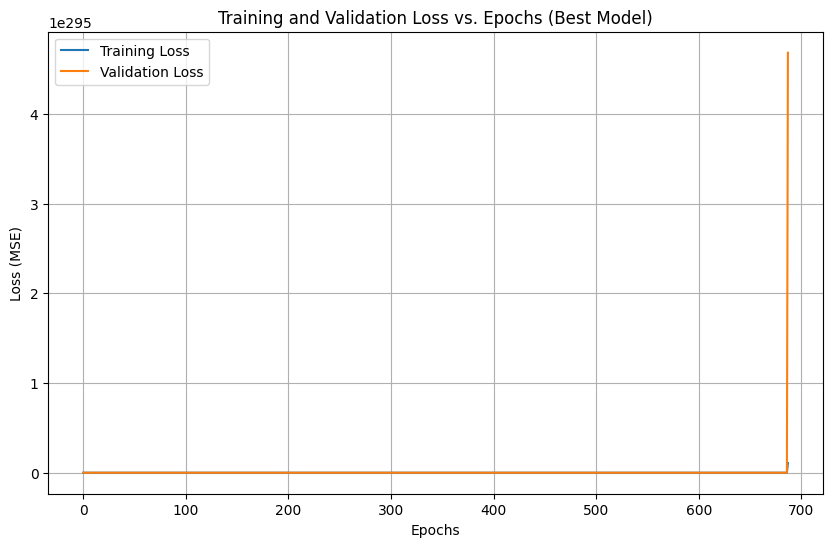

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss vs. Epochs (Best Model)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# 7. Model Evaluation – Custom NN

Test Set MSE (Scaled): 0.1656
Test Set R2 Score: 0.8400


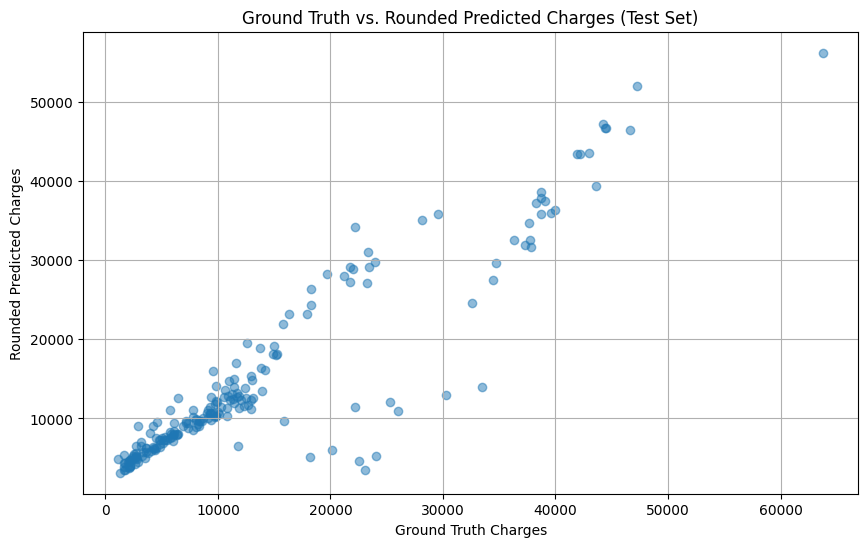

In [100]:
from sklearn.metrics import r2_score

test_predictions_scaled = best_model.forward(X_test_scaled)

test_mse_scaled = np.mean((test_predictions_scaled - y_test_scaled)**2)
print(f"Test Set MSE (Scaled): {test_mse_scaled:.4f}")

test_predictions_original = scaler_y.inverse_transform(test_predictions_scaled)
y_test_original = scaler_y.inverse_transform(y_test_scaled)

test_predictions_rounded = np.round(test_predictions_original)

test_r2 = r2_score(y_test_original, test_predictions_original)
print(f"Test Set R2 Score: {test_r2:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, test_predictions_rounded, alpha=0.5)
plt.xlabel("Ground Truth Charges")
plt.ylabel("Rounded Predicted Charges")
plt.title("Ground Truth vs. Rounded Predicted Charges (Test Set)")
plt.grid(True)
plt.show()

# 8. Sklearn MLPRegressor

In [104]:
from sklearn.neural_network import MLPRegressor

mlp_hidden_layer_sizes = tuple([best_hparams['neurons_per_layer']] * best_hparams['num_hidden_layers'])
mlp_learning_rate = 0.05
mlp_epochs = 50

mlp_model = MLPRegressor(hidden_layer_sizes=mlp_hidden_layer_sizes,
                           learning_rate_init=mlp_learning_rate,
                           max_iter=mlp_epochs,
                           random_state=42)

# Training the model
mlp_model.fit(X_train_scaled, y_train_scaled.ravel())

y_test_pred_mlp = mlp_model.predict(X_test_scaled)

In [108]:
from sklearn.metrics import mean_squared_error

test_mse_mlp = mean_squared_error(y_test_scaled.ravel(), y_test_pred_mlp)
test_r2_mlp = r2_score(y_test_scaled.ravel(), y_test_pred_mlp)

print(f"MLPRegressor Test Set MSE (Scaled): {test_mse_mlp:.4f}")
print(f"MLPRegressor Test Set R2 Score (Scaled): {test_r2_mlp:.4f}")

y_test_pred_mlp_original = scaler_y.inverse_transform(y_test_pred_mlp.reshape(-1, 1))
y_test_original = scaler_y.inverse_transform(y_test_scaled)

MLPRegressor Test Set MSE (Scaled): 0.1745
MLPRegressor Test Set R2 Score (Scaled): 0.8315


In [114]:
print("--- Model Performance Comparison (Scaled Predictions) ---")
print(f"Custom Neural Network:")
print(f"  Test Set MSE (Scaled): {test_mse_scaled:.4f}")
print(f"  Test Set R2 Score (Scaled): {test_r2:.4f}")
print("\nSklearn MLPRegressor:")
print(f"  Test Set MSE (Scaled): {test_mse_mlp:.4f}")
print(f"  Test Set R2 Score (Scaled): {test_r2_mlp:.4f}")

if abs(test_mse_scaled - test_mse_mlp) < 0.01:
    print("\nThe models' performances are quite similar")
else:
    print("\nThe performances of models differ")

--- Model Performance Comparison (Scaled Predictions) ---
Custom Neural Network:
  Test Set MSE (Scaled): 0.1656
  Test Set R2 Score (Scaled): 0.8400

Sklearn MLPRegressor:
  Test Set MSE (Scaled): 0.1745
  Test Set R2 Score (Scaled): 0.8315

The models' performances are quite similar


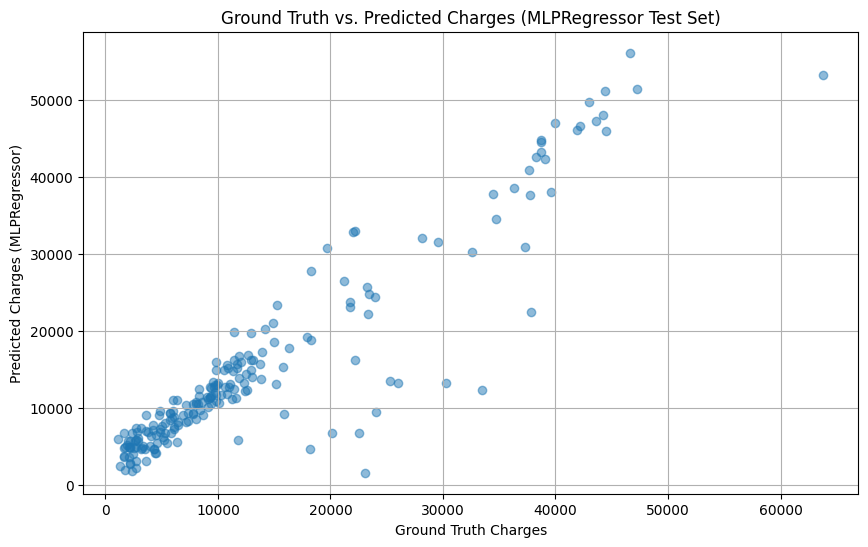

In [110]:
# Scatter plot of predictions vs ground truths for MLPRegressor
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_test_pred_mlp_original, alpha=0.5)
plt.xlabel("Ground Truth Charges")
plt.ylabel("Predicted Charges (MLPRegressor)")
plt.title("Ground Truth vs. Predicted Charges (MLPRegressor Test Set)")
plt.grid(True)
plt.show()